<a href="https://colab.research.google.com/github/Jenycantik/Kalkulator_/blob/main/Statistik%20berat%20badan%20dan%20tinggi%20badan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NIM :5231911010
NAMA  :JENY AMELINDRIKA PUTRI
PRODI :INFORMATIKA MEDIS 23

In [ ]:
import sqlite3
import numpy as np

# Membuat dan menghubungkan ke database SQLite
conn = sqlite3.connect("program statistik bmi.db")
cursor = conn.cursor()

# Membuat tabel jika belum ada(berisi beberapa parameter)
cursor.execute("""
CREATE TABLE IF NOT EXISTS pasien (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    nama TEXT NOT NULL,
    weight REAL NOT NULL,
    height REAL NOT NULL
)
""")
conn.commit()

# Fungsi untuk menambahkan data pasien baru
def masukkan_data_baru():
    jumlah = int(input("Berapa banyak data yang ingin dimasukkan? "))
    for i in range(1, jumlah + 1):  # Menggunakan indeks mulai dari 1
        print(f"\nData ke {i}")
        nama = input("Nama: ")
        weight = float(input("Berat badan(kg): "))
        height = float(input("Tinggi badan(cm): "))
        cursor.execute("INSERT INTO pasien (nama, weight, height) VALUES (?, ?, ?)",
                       (nama, weight, height))
    conn.commit()
    print(f"{jumlah} data berhasil disimpan!")
#untuk menghitung bmi
def hitung_bmi(weight, height):
    return weight / ((height / 100) ** 2)


# Fungsi untuk mengambil data dari database
def ambil_data():
    cursor.execute("SELECT weight, height FROM pasien")
    data = cursor.fetchall()
    if not data:
        print("Tidak ada data di database.")
        return None, None
    data_np = np.array(data)
    return data_np[:, 0], data_np[:, 1]

# Fungsi untuk menghitung statistik
def hitung_statistik(data):
    mean = np.mean(data)
    median = np.median(data)
    std_dev = np.std(data)
    minimum = np.min(data)
    maksimum = np.max(data)
    return mean, median, std_dev, minimum, maksimum

# Fungsi untuk menampilkan statistik
def tampilkan_statistik():
    weight, height = ambil_data()
    if weight is None:
        return
    print("\nStatistik weight:")
    mean, median, std_dev, minimum, maksimum = hitung_statistik(weight)
    print(f" Rata-rata: {mean:.2f} kg\n Median: {median:.2f} kg\n Standar Deviasi: {std_dev:.2f}\n Min: {minimum:.2f} kg\n Max: {maksimum:.2f} kg")
    print("")
    print("\nStatistik height:")
    mean, median, std_dev, minimum, maksimum = hitung_statistik(height)
    print(f" Rata-rata: {mean:.2f} kg\n Median: {median:.2f} kg\n Standar Deviasi: {std_dev:.2f}\n Min: {minimum:.2f} kg\n Max: {maksimum:.2f} kg")
    print("")
    print("\nStatistik indeks masa tubuh (bmi):")
    bmi = hitung_bmi(weight, height)
    mean, median, std_dev, minimum, maksimum = hitung_statistik(bmi)
    print(f" Rata-rata: {mean:.2f} kg\n Median: {median:.2f} kg\n Standar Deviasi: {std_dev:.2f}\n Min: {minimum:.2f} kg\n Max: {maksimum:.2f} kg")
    print("")

# Menu utama program
def menu():
    while True:
        print("\nProgram Statistik berat badan dan tinggi badan:")
        print("1. Masukkan Data Baru")
        print("2. Tampilkan Statistik Data")
        print("3. Keluar")
        pilihan = input("Pilih menu (1/2/3): ")
        if pilihan == "1":
            masukkan_data_baru()
        elif pilihan == "2":
            tampilkan_statistik()
        elif pilihan == "3":
            print("Keluar dari program.Terimakasih sudah menggunakan program ini!")
            break
        else:
            print("Pilihan tidak valid. Silakan coba lagi.")

# Menjalankan program
if __name__ == "__main__":
    menu()
    conn.close()


Program Statistik berat badan dan tinggi badan:
1. Masukkan Data Baru
2. Tampilkan Statistik Data
3. Keluar
Pilih menu (1/2/3): 2

Statistik weight:
 Rata-rata: 46.83 kg
 Median: 47.00 kg
 Standar Deviasi: 1.07
 Min: 45.00 kg
 Max: 48.00 kg


Statistik height:
 Rata-rata: 148.33 kg
 Median: 148.00 kg
 Standar Deviasi: 1.37
 Min: 147.00 kg
 Max: 150.00 kg


Statistik indeks masa tubuh (bmi):
 Rata-rata: 21.29 kg
 Median: 21.09 kg
 Standar Deviasi: 0.71
 Min: 20.27 kg
 Max: 22.21 kg


Program Statistik berat badan dan tinggi badan:
1. Masukkan Data Baru
2. Tampilkan Statistik Data
3. Keluar
Pilih menu (1/2/3): 3
Keluar dari program.Terimakasih sudah menggunakan program ini!


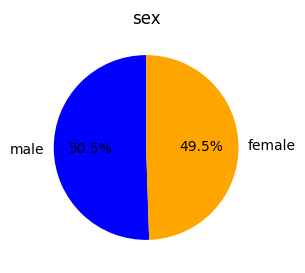

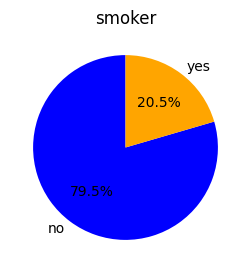

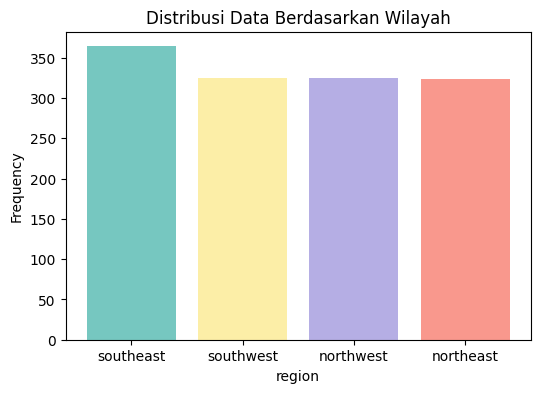

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def load_data(file_path):
    return pd.read_csv('/content/insurance (2).csv')

def plot_pie(data, column, title):
    counts = data[column].value_counts()
    plt.figure(figsize=(4, 3))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['blue', 'orange'])
    plt.title(title)
    plt.show()

def plot_bar(data, column, title):
    counts = data[column].value_counts()
    plt.figure(figsize=(6, 4))
    plt.bar(counts.index, counts, color=['#76c7c0', '#fceea7', '#b5aee4', '#f9988d'])
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

if __name__ == "__main__":
    # Provide the full path to your dataset
    file_path = "/path/to/your/dataset.csv"  # Replace with the actual full path
    data = load_data(file_path)

    # Plot pie charts
    plot_pie(data, 'sex', 'sex')
    plot_pie(data, 'smoker', 'smoker')

    # Plot bar chart
    plot_bar(data, 'region', 'Distribusi Data Berdasarkan Wilayah')
